### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 179.7       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 1515*1000
Fy_0 = 0.7*Fx_0
LTD = 209

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
# Ar=np.pi*((d0/2)**2-(dI/2)**2)
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 34 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])                ### !!! ### !!! ### !!! ###
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.0176852 , 0.4609293 , 0.96512191, 0.50205433, 0.34711811,
       0.66193539, 0.60743859, 0.53697242, 0.21579039, 0.79771036,
       0.76487804, 0.95491089, 0.08865561, 0.86265566, 0.3468302 ,
       0.77396304, 0.31453726, 0.55355663, 0.53312712, 0.51322731])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 5)

coefs = [1, 1, 1, 1, 1, 1]
vessel_motion_calibration_coefficient = 5e2 #  to control the force from the vessel   ### !!! ### !!! ### !!! ###

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.99514447,  0.        ,  0.0984096 ],
        [ 0.        ,  1.        , -0.01768428],
        [-0.09842499,  0.        ,  0.99498885]],

       [[ 0.63008538,  0.        ,  0.69548727],
        [ 0.        ,  1.        , -0.44478062],
        [-0.77652586,  0.        ,  0.56432939]],

       [[ 0.97797487,  0.        ,  0.11882929],
        [ 0.        ,  1.        , -0.82211833],
        [-0.20872267,  0.        ,  0.55677738]],

       [[ 0.64927319,  0.        ,  0.66669957],
        [ 0.        ,  1.        , -0.48122737],
        [-0.76055527,  0.        ,  0.56915016]],

       [[ 0.99077083,  0.        ,  0.12746317],
        [ 0.        ,  1.        , -0.34018921],
        [-0.13554764,  0.        ,  0.93167829]],

       [[ 0.90739965,  0.        ,  0.33150978],
        [ 0.        ,  1.        , -0.61464465],
        [-0.42026882,  0.        ,  0.71576059]],

       [[ 0.98559186,  0.        ,  0.13888384],
        [ 0.        ,  1.        , -0.57076613],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-7.72054176e-02,  0.00000000e+00,  7.78865478e-01],
        [ 0.00000000e+00,  0.00000000e+00, -9.26228311e-01],
        [-7.80599970e-01,  0.00000000e+00, -9.34960439e-02]],

       [[-5.55834157e-01,  0.00000000e+00,  3.55248772e-01],
        [ 0.00000000e+00,  0.00000000e+00, -1.26277112e-01],
        [-4.51012639e-01,  0.00000000e+00, -5.37339748e-01]],

       [[-1.03376111e-01,  0.00000000e+00,  1.69613202e-01],
        [ 0.00000000e+00,  0.00000000e+00, -3.52175507e-01],
        [-4.84371151e-01,  0.00000000e+00, -5.56209653e-01]],

       [[-4.48452417e-02,  0.00000000e+00, -2.20403625e-01],
        [ 0.00000000e+00,  0.00000000e+00, -6.08259015e-01],
        [-3.82836254e-02,  0.00000000e+00, -2.56114981e-01]],

       [[-1.21847792e-02,  0.00000000e+00,  4.06726273e-02],
        [ 0.00000000e+00,  0.00000000e+00, -8.78502162e-01],
        [-8.90633285e-02,  0.00000000e+00, -3.26337133e-01]],

       [[-3.99397876e-01,  0.00000000e+00,  5.46236242e-01],
        [ 0.00

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.96954716,  0.77584199,  0.39081862],
       [ 0.6258615 ,  0.37235575,  0.32626754],
       [ 0.62375628,  0.36529872, -0.04108516],
       [ 0.64535431, -0.08166673, -0.36141542],
       [ 0.98738568, -0.07500855,  0.3249852 ],
       [ 0.54793611,  0.8070166 , -0.05107738],
       [ 0.79181461,  0.46521087, -0.05802651],
       [ 0.80302227,  0.80055206, -0.36141357],
       [ 0.79344699,  0.84002437,  0.22526175],
       [ 0.04163828,  0.681505  ,  0.12258996],
       [ 0.32384001,  0.4737409 , -0.21330077],
       [ 0.54881124,  0.15585729,  0.05486019],
       [ 0.58197537,  0.67256953, -0.1406869 ],
       [ 0.14994087, -0.53968307,  0.45566253],
       [ 0.79876068,  0.4076585 , -0.00523862],
       [ 0.90575363,  0.0382722 ,  0.20904133],
       [ 0.75719424,  0.31663048,  0.25108512],
       [ 0.55839376, -0.13841669,  0.35327453],
       [ 0.46052993,  0.42655376, -0.1450913 ],
       [ 0.11396547,  0.72667631, -0.01902454]])

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 0.72416008,  0.32502637, -0.67321854],
       [ 1.10124344,  0.53365556, -0.87686256],
       [ 0.76039696, -0.49259418, -0.0747195 ],
       [ 0.66732951,  0.262737  ,  0.20742353],
       [ 0.26804013,  0.12376254,  0.42518237],
       [ 0.93116888,  0.0419529 , -0.7328313 ],
       [ 0.82341907,  0.23381976, -0.24967156],
       [ 0.26696862, -0.30364447, -0.23350218],
       [ 0.72662837, -0.38746223, -0.30475538],
       [ 0.4572809 , -0.02121188,  0.13554338],
       [ 0.40872664, -0.41450469, -0.26414423],
       [ 0.88230143, -0.04266056, -0.62104754],
       [ 0.78521883,  0.48173614, -0.05226547],
       [ 0.85581138,  0.24104327, -0.11801173],
       [ 0.38506804,  0.12978762, -0.42422651],
       [ 0.36354484, -0.11486938, -0.42192023],
       [ 0.34147984,  0.0226235 , -0.46058159],
       [ 0.40398988,  0.88900197, -0.49311471],
       [ 1.00923082, -0.23039119, -0.39906985],
       [ 0.13524109,  0.58831783, -0.17922883]])

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.37626225, 0.39222973, 0.30309697],
       [0.87616669, 0.05732884, 0.37525213],
       [0.25417835, 0.2380367 , 0.89317619],
       [0.05057218, 0.63882387, 0.35560318],
       [0.43227154, 0.05401105, 0.71708952],
       [0.51395391, 0.10526792, 0.23042549],
       [0.50464812, 0.78514646, 0.61146271],
       [0.90753349, 0.91654628, 0.78653785],
       [0.01851576, 0.56994982, 0.62398004],
       [0.81252144, 0.48872511, 0.49363747],
       [0.21580903, 0.3516655 , 0.93536509],
       [0.59760709, 0.89669893, 0.77889452],
       [0.39752356, 0.95655144, 0.12859341],
       [0.73617681, 0.06456276, 0.50938175],
       [0.8150065 , 0.03745106, 0.52042009],
       [0.97536207, 0.87035127, 0.19724109],
       [0.37188564, 0.01382583, 0.59115724],
       [0.58545964, 0.38420034, 0.66130381],
       [0.74854832, 0.38829945, 0.71170362],
       [0.22234622, 0.87475888, 0.26330102]])

In [44]:
theta(φ,θ,ψ)

array([[0.0176852 , 0.0985846 , 0.77830648],
       [0.4609293 , 0.88913317, 0.95992556],
       [0.96512191, 0.21026868, 0.23231551],
       [0.50205433, 0.86416791, 0.56554678],
       [0.34711811, 0.13596618, 0.83854452],
       [0.66193539, 0.43374155, 0.46409572],
       [0.60743859, 0.16995807, 0.01648992],
       [0.53697242, 0.56599748, 0.30679992],
       [0.21579039, 0.62455865, 0.83879471],
       [0.79771036, 0.32384596, 0.00244919],
       [0.76487804, 0.9760411 , 0.29742409],
       [0.95491089, 0.29493536, 0.97610675],
       [0.08865561, 0.92174798, 0.39220237],
       [0.86265566, 0.29390883, 0.45874603],
       [0.3468302 , 0.45744207, 0.04965829],
       [0.77396304, 0.17479469, 0.17218683],
       [0.31453726, 0.35571857, 0.34166027],
       [0.55355663, 0.80782433, 0.67798614],
       [0.53312712, 0.69999696, 0.95675819],
       [0.51322731, 0.69287061, 0.33894783]])

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.45544233,  0.28085772,  0.11666025],
       [ 0.88849008, -0.23097393,  0.18960252],
       [ 0.45085109,  0.01344733,  0.78016873],
       [ 0.25235713,  0.62084791,  0.25495865],
       [ 0.46679225, -0.24640247,  0.6268435 ],
       [ 0.53219257, -0.00801482,  0.1455425 ],
       [ 0.73530691,  0.48950457,  0.02181724],
       [ 0.93655853,  0.29676426, -0.42542589],
       [ 0.35222449,  0.55839702,  0.51526534],
       [ 0.87677782,  0.13033276, -0.08175947],
       [ 0.51732531,  0.15136851,  0.7834137 ],
       [ 0.87608194,  0.45844154, -0.06497545],
       [ 0.32600257,  0.90676827, -0.25652525],
       [ 0.75899678, -0.27746656,  0.32918977],
       [ 0.82779956, -0.34127428,  0.32617122],
       [ 0.71325736,  0.70705438, -0.67441327],
       [ 0.3794644 , -0.20098465,  0.54555389],
       [ 0.74936676,  0.0187754 ,  0.29154725],
       [ 0.89025061, -0.09606885,  0.199218  ],
       [ 0.33964464,  0.81669608, -0.00595816]])

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.70986791, -0.69742605,  0.0984096 ],
        [ 0.70196467,  0.71199218, -0.01768428],
        [-0.05773339,  0.08163357,  0.99498885]],

       [[ 0.64432561, -0.31802824,  0.69548727],
        [ 0.73366213,  0.5137218 , -0.44478062],
        [-0.21583417,  0.79683621,  0.56432939]],

       [[ 0.99120896, -0.05817557,  0.11882929],
        [ 0.13107459,  0.55402248, -0.82211833],
        [-0.0180069 ,  0.83046655,  0.55677738]],

       [[ 0.74430976, -0.03891867,  0.66669957],
        [ 0.46974801,  0.7401061 , -0.48122737],
        [-0.47469968,  0.67136302,  0.56915016]],

       [[ 0.69666784, -0.7059795 ,  0.12746317],
        [ 0.6993161 ,  0.62867185, -0.34018921],
        [ 0.1600341 ,  0.32613593,  0.93167829]],

       [[ 0.92704693, -0.17517206,  0.33150978],
        [ 0.35308005,  0.70536971, -0.61464465],
        [-0.12616839,  0.68685393,  0.71576059]],

       [[ 0.98704973,  0.08027525,  0.13888384],
        [ 0.01353947,  0.82100104, -0.57076613],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[-0.27735349,  0.26217554,  0.0050301 ],
       [ 0.16289635, -0.19847558, -0.35002062],
       [ 0.03437972, -0.88601958,  0.2263457 ],
       [ 0.24882437, -0.25302848,  0.41916679],
       [-0.14671482, -0.00588762,  0.08888519],
       [ 0.02853185, -0.14610554,  0.00310804],
       [ 0.16835837, -0.41258928,  0.3908354 ],
       [ 0.38172308, -0.52707125,  0.17374716],
       [-0.02926596, -0.39820894,  0.36459659],
       [ 0.2822643 , -0.57851486,  0.10815415],
       [ 0.90082743, -0.67788856,  0.04702262],
       [-0.62576653, -0.68277693,  1.26616356],
       [-0.04424303,  0.01887751, -0.00365229],
       [-0.0300861 , -0.43834451,  0.09904048],
       [ 0.233445  , -0.26336712, -0.346635  ],
       [ 0.02234348, -0.16756084,  0.62889434],
       [ 0.14510305, -0.16866626, -0.08733682],
       [ 0.29910024, -0.52954835,  0.04285706],
       [ 0.04077084, -0.45333105,  0.20445203],
       [ 0.22664244, -0.1760095 ,  0.39336262]])

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[-0.01015634, -0.05964562,  0.00778582],
       [ 0.28024101, -0.83493336,  0.638795  ],
       [ 0.01963782, -0.29526802,  0.18566443],
       [ 0.38662476, -0.4276935 ,  0.31030566],
       [-0.22501944, -0.12315918,  0.11311719],
       [ 0.04549448, -0.3144183 ,  0.22896542],
       [ 0.01784127, -0.06421373,  0.00461889],
       [ 0.16254073, -0.21756632,  0.11689082],
       [ 0.0369111 , -0.43250138,  0.31254061],
       [ 0.0824699 , -0.20305353, -0.01185396],
       [ 0.73005123, -0.57294502,  0.00274937],
       [-0.56709466, -0.80169094,  0.79701515],
       [ 0.19534401, -0.12840716,  0.25762388],
       [-0.03550655, -0.38764721,  0.31512614],
       [ 0.07278144, -0.05507151, -0.0010225 ],
       [ 0.0117047 , -0.14524319,  0.09483147],
       [ 0.01604986, -0.07805624,  0.0664923 ],
       [ 0.3072814 , -0.54283526,  0.39590466],
       [ 0.00376493, -0.74511051,  0.54305038],
       [ 0.24816318, -0.24942054,  0.13409746]])

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
#     t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[-2.77353486e+08,  2.62175543e+08,  5.03009550e+06],
       [ 1.62896353e+08, -1.98475584e+08, -3.50020623e+08],
       [ 3.43797186e+07, -8.86019575e+08,  2.26345703e+08],
       [ 2.48824369e+08, -2.53028481e+08,  4.19166789e+08],
       [-1.46714820e+08, -5.88762315e+06,  8.88851892e+07],
       [ 2.85318467e+07, -1.46105543e+08,  3.10804486e+06],
       [ 1.68358371e+08, -4.12589280e+08,  3.90835405e+08],
       [ 3.81723081e+08, -5.27071252e+08,  1.73747155e+08],
       [-2.92659630e+07, -3.98208938e+08,  3.64596587e+08],
       [ 2.82264303e+08, -5.78514857e+08,  1.08154149e+08],
       [ 9.00827432e+08, -6.77888564e+08,  4.70226239e+07],
       [-6.25766532e+08, -6.82776927e+08,  1.26616356e+09],
       [-4.42430315e+07,  1.88775087e+07, -3.65229350e+06],
       [-3.00860961e+07, -4.38344512e+08,  9.90404845e+07],
       [ 2.33445000e+08, -2.63367122e+08, -3.46634997e+08],
       [ 2.23434817e+07, -1.67560838e+08,  6.28894342e+08],
       [ 1.45103054e+08, -1.68666257e+08

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[-2.02147367e+08, -2.14775294e+08,  4.82202285e+07],
       [-1.25293478e+08,  3.65272877e+08, -2.65434641e+08],
       [-5.95139474e+07, -2.22366854e+08, -8.61404967e+08],
       [ 2.32980145e+08, -3.09601990e+08, -3.25190979e+08],
       [-8.94763855e+06, -1.47787684e+08, -2.45583025e+07],
       [ 8.34983537e+06, -8.04543468e+05, -1.14472120e+08],
       [ 2.58625626e+07, -2.49933843e+08, -2.74985843e+08],
       [ 3.65784286e+07, -1.28292458e+08, -4.69544937e+08],
       [ 3.76659356e+08, -2.54261833e+08, -2.47468130e+08],
       [-1.11078419e+08, -1.53043052e+08, -5.28728740e+08],
       [-3.11752709e+08, -4.90910104e+08, -1.10472255e+09],
       [-4.56531073e+08, -1.52832545e+09, -1.04977530e+09],
       [-6.36387519e+06, -5.98978129e+06,  4.61312823e+07],
       [ 1.02366680e+07, -9.14084857e+07, -4.01456302e+08],
       [-1.82021640e+08,  8.90347638e+07, -1.90231431e+08],
       [ 3.20029542e+07, -4.93089580e+08, -1.32514407e+08],
       [ 1.10570210e+07,  6.39306068e+07

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[  941921.60445289,   848208.11384939,  7726656.02043908],
       [ 9580408.2194573 ,  4621768.83420987,  1837906.81871031],
       [ 9714708.61305309,   192778.43287905,  -720948.0034866 ],
       [ 7030202.06597649,  5920113.24257319,  -599590.26783726],
       [ 4507980.37475157, -1492976.20846263,  7342026.85977323],
       [ 7544922.11915204,  1484876.0005854 ,   539906.22753564],
       [ 6009767.10832292,  1605461.88962633,  -893977.95671742],
       [ 5946028.19226665,  4090580.11487415,  -654451.12230701],
       [ 6541545.91100436,  4449562.98106343,  5384856.73613202],
       [ 7567885.25531939,  3220929.25672729, -2522218.79990011],
       [ 6063006.51834533,  7700900.78376212, -5133061.4486988 ],
       [10775858.99104784, -5018237.49645413,  2619594.53544194],
       [ 3648105.68276109,  8870225.71254   ,  1654989.79348502],
       [ 9121030.00276617,  -545420.62278241,   356763.68399844],
       [ 3317967.83814578,  4405623.00744713, -1112793.7288473 ],
       [ 7

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[ 1.16415322e-10,  5.43089222e-11, -1.45519152e-11],
       [ 2.32830644e-10, -3.45322824e-10,  0.00000000e+00],
       [ 3.63797881e-12, -1.69683952e-10,  2.91038305e-11],
       [-1.74622983e-10,  1.54477719e-10,  0.00000000e+00],
       [-4.65661287e-10, -6.60220149e-10,  2.32830644e-10],
       [-2.91038305e-11,  9.56618496e-11,  0.00000000e+00],
       [ 2.91038305e-11, -1.81062638e-10,  0.00000000e+00],
       [ 1.16415322e-10, -1.99042977e-10,  0.00000000e+00],
       [ 0.00000000e+00,  9.12561261e-11,  0.00000000e+00],
       [-2.32830644e-10,  3.01275475e-10, -4.65661287e-10],
       [-4.65661287e-10, -1.97200888e-10, -9.31322575e-10],
       [-6.98491931e-10, -1.16974518e-09,  9.31322575e-10],
       [ 2.32830644e-10, -1.04690570e-10,  0.00000000e+00],
       [ 1.09139364e-11, -4.58267337e-11, -2.91038305e-10],
       [ 5.82076609e-11,  5.18336021e-11,  2.32830644e-10],
       [ 0.00000000e+00,  3.42506725e-11,  1.74622983e-10],
       [ 1.74622983e-10, -1.48267125e-10

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[ 31.60854335, 175.61011129, 333.76725067],
       [ 46.6907178 , 402.91139525, 288.76810986],
       [  4.36239249, 482.02497319, 442.13468554],
       [  8.83685371, 258.53059112,  41.71053719],
       [316.62909188, 394.68704962, 338.13612571],
       [ 17.19760568,  55.79490083, 361.81559982],
       [211.08445395, 260.92539688,  43.835761  ],
       [111.86563394,  37.12077766, 129.95480909],
       [309.76529532, 232.42403521,  40.3533703 ],
       [ 44.66049854, 158.36612418, 342.1598713 ],
       [ 11.92337585, 141.31924983, 280.9671733 ],
       [374.95432082, 405.45172702, 422.56730882],
       [ 22.33972621,  40.03729691,  13.11526855],
       [ 60.58111269,  33.62791457,  74.12011851],
       [  7.36902524,  11.53331752,  34.90488697],
       [208.7675091 , 195.64855148, 289.42057241],
       [ 24.25582809,  64.74972924, 199.16071624],
       [ 21.92583217,  12.59420881, 298.11050619],
       [ 47.53510549,  79.16705404,  17.06507182],
       [  4.72964201, 107.05202

In [60]:
fg_e = np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = phi(x,y,z)*e3+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i][j]<0:
                k0[i][j]=0
            elif 0<=k[i][j]<=d0/20:
                k0[i][j]=(fg_e2*10*k[i][j]**2)/((d0/8-d0/40)*d0)
            else:
                k0[i][j]=(fg_e2*(k[i][j]-d0/40))/(d0/8-d0/40)
                
    return k0         

In [63]:
sigma(x,y,z)

array([[ 5845.36330569,  5845.36330569, 13187.72505213],
       [ 5845.36330569,  5845.36330569, 14935.64519425],
       [ 5845.36330569,  5845.36330569, 27482.07817691],
       [ 5845.36330569,  5845.36330569, 14459.66000541],
       [ 5845.36330569,  5845.36330569, 23216.47297126],
       [ 5845.36330569,  5845.36330569, 11427.29733779],
       [ 5845.36330569,  5845.36330569, 20657.72013705],
       [ 5845.36330569,  5845.36330569, 24898.82151024],
       [ 5845.36330569,  5845.36330569, 20960.94568619],
       [ 5845.36330569,  5845.36330569, 17803.46666344],
       [ 5845.36330569,  5845.36330569, 28504.08169949],
       [ 5845.36330569,  5845.36330569, 24713.66607118],
       [ 5845.36330569,  5845.36330569,  8960.46974645],
       [ 5845.36330569,  5845.36330569, 18184.86359076],
       [ 5845.36330569,  5845.36330569, 18452.26122923],
       [ 5845.36330569,  5845.36330569, 10623.42301072],
       [ 5845.36330569,  5845.36330569, 20165.83104916],
       [ 5845.36330569,  5845.3

In [64]:
def ne_hat(x,y,z,dx,dy,dz):
    return fg_e.T - fD(dx,dy,dz) # - sigma(x,y,z).T

In [65]:
ne_hat(x,y,z,dx,dy,dz).T

array([[ -31.60854335, -175.61011129, -608.93840235],
       [ -46.6907178 , -402.91139525, -563.93926154],
       [  -4.36239249, -482.02497319, -717.30583722],
       [  -8.83685371, -258.53059112, -316.88168887],
       [-316.62909188, -394.68704962, -613.30727739],
       [ -17.19760568,  -55.79490083, -636.9867515 ],
       [-211.08445395, -260.92539688, -319.00691268],
       [-111.86563394,  -37.12077766, -405.12596076],
       [-309.76529532, -232.42403521, -315.52452198],
       [ -44.66049854, -158.36612418, -617.33102297],
       [ -11.92337585, -141.31924983, -556.13832498],
       [-374.95432082, -405.45172702, -697.7384605 ],
       [ -22.33972621,  -40.03729691, -288.28642023],
       [ -60.58111269,  -33.62791457, -349.29127019],
       [  -7.36902524,  -11.53331752, -310.07603865],
       [-208.7675091 , -195.64855148, -564.59172408],
       [ -24.25582809,  -64.74972924, -474.33186792],
       [ -21.92583217,  -12.59420881, -573.28165787],
       [ -47.53510549,  -79.

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', RET, Jrho0, RET)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[ 1.00968445e+02, -1.74030305e-01,  9.79164538e+00],
        [-1.74030305e-01,  1.00031273e+02, -1.75956629e+00],
        [ 9.79164538e+00, -1.75956629e+00,  1.99000282e+02]],

       [[ 1.48370254e+02, -3.09339258e+01,  3.92483906e+01],
        [-3.09339258e+01,  1.19782980e+02, -2.51002773e+01],
        [ 3.92483906e+01, -2.51002773e+01,  1.31846766e+02]],

       [[ 1.01412040e+02, -9.76917385e+00,  6.61614621e+00],
        [-9.76917385e+00,  1.67587854e+02, -4.57736892e+01],
        [ 6.61614621e+00, -4.57736892e+01,  1.31000106e+02]],

       [[ 1.44448832e+02, -3.20834078e+01,  3.79452167e+01],
        [-3.20834078e+01,  1.23157978e+02, -2.73890633e+01],
        [ 3.79452167e+01, -2.73890633e+01,  1.32393191e+02]],

       [[ 1.01624686e+02, -4.33615960e+00,  1.18754669e+01],
        [-4.33615960e+00,  1.11572870e+02, -3.16946906e+01],
        [ 1.18754669e+01, -3.16946906e+01,  1.86802444e+02]],

       [[ 1.10989873e+02, -2.03760712e+01,  2.37281636e+01],
        [-2.03

### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 11.027354079515861,
 22.056523745356273,
 33.08932488275457,
 44.127573974810836,
 55.17308840154847,
 66.22768673911834,
 77.29318905920005,
 88.3714172286495,
 99.46419520944222,
 110.5733493589617,
 121.70070873068227,
 132.84810537529617,
 144.01737464233418,
 155.21035548232967,
 166.42889074957577,
 177.6748275055255,
 188.95001732288486,
 200.2563165904489,
 211.59558681873108]

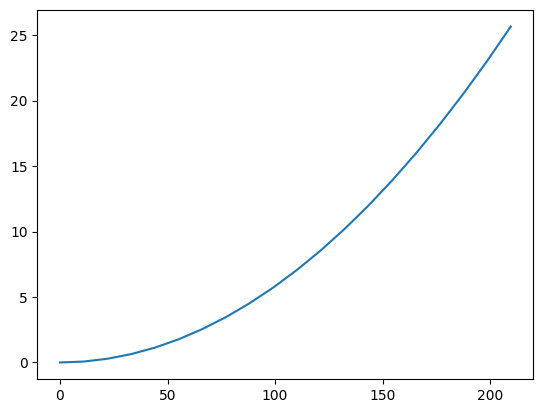

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)

    η = [x[-1],y[-1],z[-1],φ[-1],θ[-1],ψ[-1]]

    tau_force = np.array([-Fx_0,Fy_0,0,0,0,0])

    Z0 = tau_force[:3]    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T


    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,kp->ijp', Π(φ,θ,ψ), tau_force[3:].reshape(3,1))
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0.squeeze())
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################

    ans=np.concatenate([dx, ddx, dy, ddy, dz, ddz, dφ, ddφ, dθ, ddθ, dψ, ddψ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='df-sane')

In [83]:
root_

 message: too many function evaluations required
 success: False
     fun: [ 6.224e+01  6.224e+01 ...  0.000e+00  0.000e+00]
       x: [ 1.058e+03  1.069e+03 ...  0.000e+00  0.000e+00]
     nit: 330
    nfev: 1000
  method: df-sane

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
# q0 = root_.x                                            # start from static solution

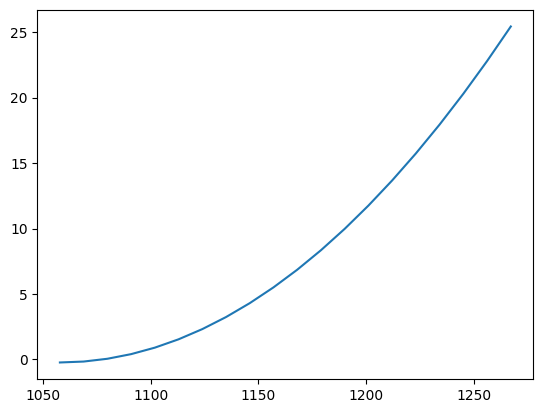

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Finite Element Model of the Space Frame Element

In [87]:
def PlaneTrussElementLength(x1,y1,z1,x2,y2,z2):
    return np.sqrt((x2-x1)*(x2-x1) + (y2-y1)*(y2-y1)+(z2-z1)*(z2-z1))

In [88]:
def SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,x1,y1,z1,x2,y2,z2):
    L = PlaneTrussElementLength(x1,y1,z1,x2,y2,z2)
    w1 = E*A/L
    w2 = 12*E*Iz/(L*L*L)
    w3 = 6*E*Iz/(L*L)
    w4 = 4*E*Iz/L
    w5 = 2*E*Iz/L
    w6 = 12*E*Iy/(L*L*L)
    w7 = 6*E*Iy/(L*L)
    w8 = 4*E*Iy/L
    w9 = 2*E*Iy/L
    w10 = G*J/L

    kprime = np.array([[w1, 0, 0, 0, 0, 0, -w1, 0, 0, 0, 0, 0],
                        [0, w2, 0, 0, 0, w3, 0, -w2, 0, 0, 0, w3],
                        [0, 0, w6, 0, -w7, 0, 0, 0, -w6, 0, -w7, 0],
                        [0, 0, 0, w10, 0, 0, 0, 0, 0, -w10, 0, 0],
                        [0, 0, -w7, 0, w8, 0, 0, 0, w7, 0, w9, 0],
                        [0, w3, 0, 0, 0, w4, 0, -w3, 0, 0, 0, w5],
                        [-w1, 0, 0, 0, 0, 0, w1, 0, 0, 0, 0, 0],
                        [0, -w2, 0, 0, 0, -w3, 0, w2, 0, 0, 0, -w3],
                        [0, 0, -w6, 0, w7, 0, 0, 0, w6, 0, w7, 0],
                        [0, 0, 0, -w10, 0, 0, 0, 0, 0, w10, 0, 0],
                        [0, 0, -w7, 0, w9, 0, 0, 0, w7, 0, w8, 0],
                        [0, w3, 0, 0, 0, w5, 0, -w3, 0, 0, 0, w4]])


    if x1 == x2 and y1 == y2:
        if z2 > z1:
            Lambda = np.array([[0, 0, 1], [0, 1, 0], [-1, 0, 0]])
        else:
            Lambda = np.array([[0, 0, -1], [0, 1, 0], [1, 0, 0]])
    else:
        CXx = (x2-x1)/L
        CYx = (y2-y1)/L
        CZx = (z2-z1)/L
        D = np.sqrt(CXx*CXx + CYx*CYx)
        CXy = -CYx/D
        CYy = CXx/D
        CZy = 0
        CXz = -CXx*CZx/D
        CYz = -CYx*CZx/D
        CZz = D
        Lambda = np.array([[CXx, CYx, CZx], [CXy, CYy, CZy], [CXz, CYz, CZz]])


    R = np.array([np.concatenate((np.concatenate((Lambda,np.zeros((3,3)),np.zeros((3,3)),np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), Lambda, np.zeros((3,3)), np.zeros((3,3))),axis=1) ,
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), Lambda, np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), np.zeros((3,3)), Lambda),axis=1)))])[0]
    return np.dot(np.dot(R.T,kprime),R)

In [89]:
def SpaceFrameAssemble(K,k,i,j):
    K[6*i,6*i] = K[6*i,6*i] + k[0,0]
    K[6*i,6*i+1] = K[6*i,6*i+1] + k[0,1]
    K[6*i,6*i+2] = K[6*i,6*i+2] + k[0,2]
    K[6*i,6*i+3] = K[6*i,6*i+3] + k[0,3]
    K[6*i,6*i+4] = K[6*i,6*i+4] + k[0,4]
    K[6*i,6*i+5] = K[6*i,6*i+5] + k[0,5]
    K[6*i,6*j] = K[6*i,6*j] + k[0,6]
    K[6*i,6*j+1] = K[6*i,6*j+1] + k[0,7]
    K[6*i,6*j+2] = K[6*i,6*j+2] + k[0,8]
    K[6*i,6*j+3] = K[6*i,6*j+3] + k[0,9]
    K[6*i,6*j+4] = K[6*i,6*j+4] + k[0,10]
    K[6*i,6*j+5] = K[6*i,6*j+5] + k[0,11]
    K[6*i+1,6*i] = K[6*i+1,6*i] + k[1,0]
    K[6*i+1,6*i+1] = K[6*i+1,6*i+1] + k[1,1]
    K[6*i+1,6*i+2] = K[6*i+1,6*i+2] + k[1,2]
    K[6*i+1,6*i+3] = K[6*i+1,6*i+3] + k[1,3]
    K[6*i+1,6*i+4] = K[6*i+1,6*i+4] + k[1,4]
    K[6*i+1,6*i+5] = K[6*i+1,6*i+5] + k[1,5]
    K[6*i+1,6*j] = K[6*i+1,6*j] + k[1,6]
    K[6*i+1,6*j+1] = K[6*i+1,6*j+1] + k[1,7]
    K[6*i+1,6*j+2] = K[6*i+1,6*j+2] + k[1,8]
    K[6*i+1,6*j+3] = K[6*i+1,6*j+3] + k[1,9]
    K[6*i+1,6*j+4] = K[6*i+1,6*j+4] + k[1,10]
    K[6*i+1,6*j+5] = K[6*i+1,6*j+5] + k[1,11]
    K[6*i+2,6*i]   = K[6*i+2,6*i] + k[2,0]
    K[6*i+2,6*i+1] = K[6*i+2,6*i+1] + k[2,1]
    K[6*i+2,6*i+2] = K[6*i+2,6*i+2] + k[2,2]
    K[6*i+2,6*i+3] = K[6*i+2,6*i+3] + k[2,3]
    K[6*i+2,6*i+4] = K[6*i+2,6*i+4] + k[2,4]
    K[6*i+2,6*i+5] = K[6*i+2,6*i+5] + k[2,5]
    K[6*i+2,6*j]   = K[6*i+2,6*j] + k[2,6]
    K[6*i+2,6*j+1] = K[6*i+2,6*j+1] + k[2,7]
    K[6*i+2,6*j+2] = K[6*i+2,6*j+2] + k[2,8]
    K[6*i+2,6*j+3] = K[6*i+2,6*j+3] + k[2,9]
    K[6*i+2,6*j+4] = K[6*i+2,6*j+4] + k[2,10]
    K[6*i+2,6*j+5] = K[6*i+2,6*j+5] + k[2,11]
    K[6*i+3,6*i] = K[6*i+3,6*i] + k[3,0]
    K[6*i+3,6*i+1] = K[6*i+3,6*i+1] + k[3,1]
    K[6*i+3,6*i+2] = K[6*i+3,6*i+2] + k[3,2]
    K[6*i+3,6*i+3] = K[6*i+3,6*i+3] + k[3,3]
    K[6*i+3,6*i+4] = K[6*i+3,6*i+4] + k[3,4]
    K[6*i+3,6*i+5] = K[6*i+3,6*i+5] + k[3,5]
    K[6*i+3,6*j] = K[6*i+3,6*j] + k[3,6]
    K[6*i+3,6*j+1] = K[6*i+3,6*j+1] + k[3,7]
    K[6*i+3,6*j+2] = K[6*i+3,6*j+2] + k[3,8]
    K[6*i+3,6*j+3] = K[6*i+3,6*j+3] + k[3,9]
    K[6*i+3,6*j+4] = K[6*i+3,6*j+4] + k[3,10]
    K[6*i+3,6*j+5] = K[6*i+3,6*j+5] + k[3,11]
    K[6*i+4,6*i] = K[6*i+4,6*i] + k[4,0]
    K[6*i+4,6*i+1] = K[6*i+4,6*i+1] + k[4,1]
    K[6*i+4,6*i+2] = K[6*i+4,6*i+2] + k[4,2]
    K[6*i+4,6*i+3] = K[6*i+4,6*i+3] + k[4,3]
    K[6*i+4,6*i+4] = K[6*i+4,6*i+4] + k[4,4]
    K[6*i+4,6*i+5] = K[6*i+4,6*i+5] + k[4,5]
    K[6*i+4,6*j] = K[6*i+4,6*j] + k[4,6]
    K[6*i+4,6*j+1] = K[6*i+4,6*j+1] + k[4,7]
    K[6*i+4,6*j+2] = K[6*i+4,6*j+2] + k[4,8]
    K[6*i+4,6*j+3] = K[6*i+4,6*j+3] + k[4,9]
    K[6*i+4,6*j+4] = K[6*i+4,6*j+4] + k[4,10]
    K[6*i+4,6*j+5] = K[6*i+4,6*j+5] + k[4,11]
    K[6*i+5,6*i] = K[6*i+5,6*i] + k[5,0]
    K[6*i+5,6*i+1] = K[6*i+5,6*i+1] + k[5,1]
    K[6*i+5,6*i+2] = K[6*i+5,6*i+2] + k[5,2]
    K[6*i+5,6*i+3] = K[6*i+5,6*i+3] + k[5,3]
    K[6*i+5,6*i+4] = K[6*i+5,6*i+4] + k[5,4]
    K[6*i+5,6*i+5] = K[6*i+5,6*i+5] + k[5,5]
    K[6*i+5,6*j] = K[6*i+5,6*j] + k[5,6]
    K[6*i+5,6*j+1] = K[6*i+5,6*j+1] + k[5,7]
    K[6*i+5,6*j+2] = K[6*i+5,6*j+2] + k[5,8]
    K[6*i+5,6*j+3] = K[6*i+5,6*j+3] + k[5,9]
    K[6*i+5,6*j+4] = K[6*i+5,6*j+4] + k[5,10]
    K[6*i+5,6*j+5] = K[6*i+5,6*j+5] + k[5,11]
    K[6*j,6*i] = K[6*j,6*i] + k[6,0]
    K[6*j,6*i+1] = K[6*j,6*i+1] + k[6,1]
    K[6*j,6*i+2] = K[6*j,6*i+2] + k[6,2]
    K[6*j,6*i+3] = K[6*j,6*i+3] + k[6,3]
    K[6*j,6*i+4] = K[6*j,6*i+4] + k[6,4]
    K[6*j,6*i+5] = K[6*j,6*i+5] + k[6,5]
    K[6*j,6*j] = K[6*j,6*j] + k[6,6]
    K[6*j,6*j+1] = K[6*j,6*j+1] + k[6,7]
    K[6*j,6*j+2] = K[6*j,6*j+2] + k[6,8]
    K[6*j,6*j+3] = K[6*j,6*j+3] + k[6,9]
    K[6*j,6*j+4] = K[6*j,6*j+4] + k[6,10]
    K[6*j,6*j+5] = K[6*j,6*j+5] + k[6,11]
    K[6*j+1,6*i] = K[6*j+1,6*i] + k[7,0]
    K[6*j+1,6*i+1] = K[6*j+1,6*i+1] + k[7,1]
    K[6*j+1,6*i+2] = K[6*j+1,6*i+2] + k[7,2]
    K[6*j+1,6*i+3] = K[6*j+1,6*i+3] + k[7,3]
    K[6*j+1,6*i+4] = K[6*j+1,6*i+4] + k[7,4]
    K[6*j+1,6*i+5] = K[6*j+1,6*i+5] + k[7,5]
    K[6*j+1,6*j] = K[6*j+1,6*j] + k[7,6]
    K[6*j+1,6*j+1] = K[6*j+1,6*j+1] + k[7,7]
    K[6*j+1,6*j+2] = K[6*j+1,6*j+2] + k[7,8]
    K[6*j+1,6*j+3] = K[6*j+1,6*j+3] + k[7,9]
    K[6*j+1,6*j+4] = K[6*j+1,6*j+4] + k[7,10]
    K[6*j+1,6*j+5] = K[6*j+1,6*j+5] + k[7,11]
    K[6*j+2,6*i] = K[6*j+2,6*i] + k[8,0]
    K[6*j+2,6*i+1] = K[6*j+2,6*i+1] + k[8,1]
    K[6*j+2,6*i+2] = K[6*j+2,6*i+2] + k[8,2]
    K[6*j+2,6*i+3] = K[6*j+2,6*i+3] + k[8,3]
    K[6*j+2,6*i+4] = K[6*j+2,6*i+4] + k[8,4]
    K[6*j+2,6*i+5] = K[6*j+2,6*i+5] + k[8,5]
    K[6*j+2,6*j] = K[6*j+2,6*j] + k[8,6]
    K[6*j+2,6*j+1] = K[6*j+2,6*j+1] + k[8,7]
    K[6*j+2,6*j+2] = K[6*j+2,6*j+2] + k[8,8]
    K[6*j+2,6*j+3] = K[6*j+2,6*j+3] + k[8,9]
    K[6*j+2,6*j+4] = K[6*j+2,6*j+4] + k[8,10]
    K[6*j+2,6*j+5] = K[6*j+2,6*j+5] + k[8,11]
    K[6*j+3,6*i] = K[6*j+3,6*i] + k[9,0]
    K[6*j+3,6*i+1] = K[6*j+3,6*i+1] + k[9,1]
    K[6*j+3,6*i+2] = K[6*j+3,6*i+2] + k[9,2]
    K[6*j+3,6*i+3] = K[6*j+3,6*i+3] + k[9,3]
    K[6*j+3,6*i+4] = K[6*j+3,6*i+4] + k[9,4]
    K[6*j+3,6*i+5] = K[6*j+3,6*i+5] + k[9,5]
    K[6*j+3,6*j] = K[6*j+3,6*j] + k[9,6]
    K[6*j+3,6*j+1] = K[6*j+3,6*j+1] + k[9,7]
    K[6*j+3,6*j+2] = K[6*j+3,6*j+2] + k[9,8]
    K[6*j+3,6*j+3] = K[6*j+3,6*j+3] + k[9,9]
    K[6*j+3,6*j+4] = K[6*j+3,6*j+4] + k[9,10]
    K[6*j+3,6*j+5] = K[6*j+3,6*j+5] + k[9,11]
    K[6*j+4,6*i] = K[6*j+4,6*i] + k[10,0]
    K[6*j+4,6*i+1] = K[6*j+4,6*i+1] + k[10,1]
    K[6*j+4,6*i+2] = K[6*j+4,6*i+2] + k[10,2]
    K[6*j+4,6*i+3] = K[6*j+4,6*i+3] + k[10,3]
    K[6*j+4,6*i+4] = K[6*j+4,6*i+4] + k[10,4]
    K[6*j+4,6*i+5] = K[6*j+4,6*i+5] + k[10,5]
    K[6*j+4,6*j] = K[6*j+4,6*j] + k[10,6]
    K[6*j+4,6*j+1] = K[6*j+4,6*j+1] + k[10,7]
    K[6*j+4,6*j+2] = K[6*j+4,6*j+2] + k[10,8]
    K[6*j+4,6*j+3] = K[6*j+4,6*j+3] + k[10,9]
    K[6*j+4,6*j+4] = K[6*j+4,6*j+4] + k[10,10]
    K[6*j+4,6*j+5] = K[6*j+4,6*j+5] + k[10,11]
    K[6*j+5,6*i] = K[6*j+5,6*i] + k[11,0]
    K[6*j+5,6*i+1] = K[6*j+5,6*i+1] + k[11,1]
    K[6*j+5,6*i+2] = K[6*j+5,6*i+2] + k[11,2]
    K[6*j+5,6*i+3] = K[6*j+5,6*i+3] + k[11,3]
    K[6*j+5,6*i+4] = K[6*j+5,6*i+4] + k[11,4]
    K[6*j+5,6*i+5] = K[6*j+5,6*i+5] + k[11,5]
    K[6*j+5,6*j] = K[6*j+5,6*j] + k[11,6]
    K[6*j+5,6*j+1] = K[6*j+5,6*j+1] + k[11,7]
    K[6*j+5,6*j+2] = K[6*j+5,6*j+2] + k[11,8]
    K[6*j+5,6*j+3] = K[6*j+5,6*j+3] + k[11,9]
    K[6*j+5,6*j+4] = K[6*j+5,6*j+4] + k[11,10]
    K[6*j+5,6*j+5] = K[6*j+5,6*j+5] + k[11,11]

    return K

In [90]:
def FEA(coord, elcon, bc_node, bc_val, vessel_movement, coefs,
          E=210e6, G=84e6, A=2e-2, Iy=10e-5, Iz=20e-5, J=5e-5):

    coord=np.array(coord)
    elcon=np.array(elcon)

    K=np.zeros(shape=(6*(np.max(elcon)+1),6*(np.max(elcon)+1)))

    for el in elcon:
        k=SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,
                                     coord[el[0]][0],coord[el[0]][1],coord[el[0]][2],\
                                     coord[el[1]][0],coord[el[1]][1],coord[el[1]][2])
        K=SpaceFrameAssemble(K,k,el[0],el[1])
          
    glob_force=np.dot(K, np.array(vessel_movement))
    
    glob_force[-6:]=np.multiply(glob_force[-6:], coefs)
#     glob_force = np.zeros(len(vessel_movement))


    F=np.zeros(len(coord)*6)
    for i in range(len(vessel_movement)):
        if vessel_movement[i]:
            F[i]=glob_force[i]

    # https://github.com/CALFEM/calfem-matlab/blob/master/fem/solveq.m

    bc=np.array([bc_node,
                bc_val]).T
    nd, nd=K.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    s=scipy.linalg.lstsq(K[fdof,:][:,fdof], (F[fdof].T-np.dot(K[fdof,:][:,pdof],dp.T)).T, check_finite=True)[0]
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
    

#     Q=np.dot(K,d).T-F
    return d, np.dot(K,d).T

In [91]:
# 10 The Space Frame Element - verification
d,f=FEA(np.array([0,0,0,
                  3,0,0,
                  0,0,-3,
                  0,-4,0]).reshape(4,3),
        elcon=np.array([[0, 1],
                      [0, 2],
                      [0, 3]]),
        bc_node=list(range(3)),
        bc_val=[ -0.0705e-4, -0.0007e-4, 0.1418e-4],
        vessel_movement=[ 0, 0, 0, 0, 
                          0, 0, 0, 0,
                          0, 0, 0, 0,
                          0, 0, 0, 0,
                          0, 0, 0, 0,
                          0, 0, 0, 0,],
        coefs=[1,1,1,1,1,1])

In [92]:
d

array([-7.05000000e-06, -7.00000000e-08,  1.41800000e-05,  1.96310345e-06,
        9.72272727e-07,  9.79655172e-07, -7.05000000e-06,  2.86896552e-06,
        1.12631818e-05,  1.96310345e-06,  9.72272727e-07,  9.79655172e-07,
       -9.96681818e-06,  5.81931034e-06,  1.41800000e-05,  1.96310345e-06,
        9.72272727e-07,  9.79655172e-07, -3.13137931e-06, -7.00000000e-08,
        6.32758621e-06,  1.96310345e-06,  9.72272727e-07,  9.79655172e-07])

In [93]:
f

array([-1.23512311e-14,  9.68138330e-16, -7.45931095e-15, -2.01227923e-16,
        5.06252534e-16,  2.29677388e-15,  1.48562803e-14, -3.41740525e-16,
        3.38328676e-16, -8.50373645e-16, -5.79282444e-16,  7.32053307e-16,
       -2.39507036e-17,  4.52667960e-16,  8.83906663e-15,  1.05980762e-17,
        9.61707656e-16,  8.35492970e-16, -6.86950496e-16, -1.06528284e-15,
        7.63278329e-17,  1.38777878e-17,  3.93179989e-17, -6.93889390e-17])

In [94]:
def PipeForce(X,Y,Z,vessel_movement,coefs, E=E, G=G, A=Ar, Iy=Iy_, Iz=Iz_, J=J_):
    coord=np.stack((X,Y,Z)).T
    elcon=[]
    for i in range(1,len(X)):
        elcon.append([i-1,i])
    
#     bc_node = list(range(3))+list(range((6*len(X)-6),6*len(X)))
#     bc_val = [0]*3 + vessel_movement
    
    bc_node = list(range(3))
    bc_val = [0]*3 
    
#     vessel_move=np.zeros(len(X)*6)

    d, f = FEA(coord, elcon, bc_node, bc_val, vessel_movement, coefs, E,G,A,Iy,Iz,J)

    fors=[]
    for i in range(0,len(f),6):
        fors.append(f[i:i+3])

    mom =[]
    for i in range(3,len(f),6):
        mom.append(f[i:i+3])

    angle=[]
    for i in range(3,len(d),6):
        angle.append(d[i:i+3])
    fors[0][0]=0
    fors[0][1]=0
    fors[0][2]=0
    return np.array(fors), np.array(mom), np.array(angle)

In [95]:
fors, mom, angle = PipeForce(x0_,list([0 for i in range(len(z0))]),z0_,
[0 for i in range(6*len(z0)-6)]+[ 0.01,
 0.02,
 0.03,
 0.01,
 -0.05,
 0.03],
 [1,1,1,1,1,1])

In [96]:
fors

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.94087391e+06, -8.33617920e+07,  2.41572673e+07],
       [ 1.30250222e+06, -1.47226624e+08,  7.75909715e+07],
       [ 1.79521217e+06, -1.90087168e+08,  1.06453844e+08],
       [-1.10116395e+07, -2.11550208e+08,  1.40984330e+08],
       [-1.30551776e+07, -2.28065280e+08,  1.76350699e+08],
       [-1.10469454e+07, -2.25443840e+08,  2.16353057e+08],
       [-1.23222200e+07, -2.03390976e+08,  2.50004340e+08],
       [-1.27912083e+07, -1.63315712e+08,  2.76547253e+08],
       [-1.83720425e+07, -1.08003328e+08,  3.15983470e+08],
       [-2.27829483e+07, -2.70008320e+07,  3.52408832e+08],
       [-2.71106547e+07,  5.88513280e+07,  3.84170507e+08],
       [-3.24114663e+07,  1.71573248e+08,  4.21897258e+08],
       [-3.83779868e+07,  2.97795584e+08,  4.57893917e+08],
       [-4.42951665e+07,  4.32275456e+08,  4.92526332e+08],
       [-5.04446001e+07,  5.98688184e+08,  5.26020213e+08],
       [-5.77338959e+07,  7.79535230e+08

In [97]:
mom

array([[-1.30418688e+08, -2.22773670e+07, -5.24288000e+06],
       [-1.23080704e+08,  1.04857129e+07, -2.04472320e+07],
       [-1.19824384e+08,  1.54921757e+05, -2.17579520e+07],
       [-1.28663552e+08, -2.73249032e+07, -3.30301440e+07],
       [-1.14098176e+08, -2.92243627e+07, -1.99229440e+07],
       [-1.18235136e+08, -1.07320876e+07, -1.95297280e+07],
       [-1.07610112e+08, -1.38984460e+07, -1.78257920e+07],
       [-1.21176064e+08, -1.58006159e+07, -2.35929600e+07],
       [-1.21110528e+08,  2.62569605e+04,  1.04857600e+06],
       [-1.18640640e+08,  1.75965023e+07, -2.80494080e+07],
       [-1.19537664e+08, -5.76648394e+06, -2.09715200e+07],
       [-1.16588544e+08, -1.57329483e+07, -3.77487360e+07],
       [-1.15605504e+08,  2.99009177e+06, -3.04087040e+07],
       [-1.19537664e+08, -1.48063452e+07, -2.88358400e+06],
       [-1.17571584e+08, -3.23841724e+07, -2.51658240e+07],
       [-1.14135128e+08, -2.13517672e+07, -3.71293300e+07],
       [-1.20128610e+08, -9.50136177e+06

In [98]:
angle

array([[ 1.11437679e+10, -3.12138297e+00,  1.04847353e+09],
       [ 1.11437679e+10, -3.06690676e+00,  1.04847353e+09],
       [ 1.11437679e+10, -2.90457535e+00,  1.04847353e+09],
       [ 1.11437679e+10, -2.63740451e+00,  1.04847353e+09],
       [ 1.11437680e+10, -2.27048437e+00,  1.04847354e+09],
       [ 1.11437680e+10, -1.81070793e+00,  1.04847354e+09],
       [ 1.11437681e+10, -1.26694489e+00,  1.04847355e+09],
       [ 1.11437682e+10, -6.49984360e-01,  1.04847356e+09],
       [ 1.11437683e+10,  2.73818970e-02,  1.04847357e+09],
       [ 1.11437685e+10,  7.50615120e-01,  1.04847358e+09],
       [ 1.11437686e+10,  1.50331211e+00,  1.04847359e+09],
       [ 1.11437687e+10,  2.26710165e+00,  1.04847361e+09],
       [ 1.11437688e+10,  3.02154922e+00,  1.04847363e+09],
       [ 1.11437689e+10,  3.74399924e+00,  1.04847364e+09],
       [ 1.11437690e+10,  4.40972555e+00,  1.04847366e+09],
       [ 1.11437690e+10,  4.99177891e+00,  1.04847366e+09],
       [ 1.11437691e+10,  5.46085626e+00

### Vessle Simulation

In [99]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [100]:
Number*sampleTime

600.0

In [101]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [102]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [103]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

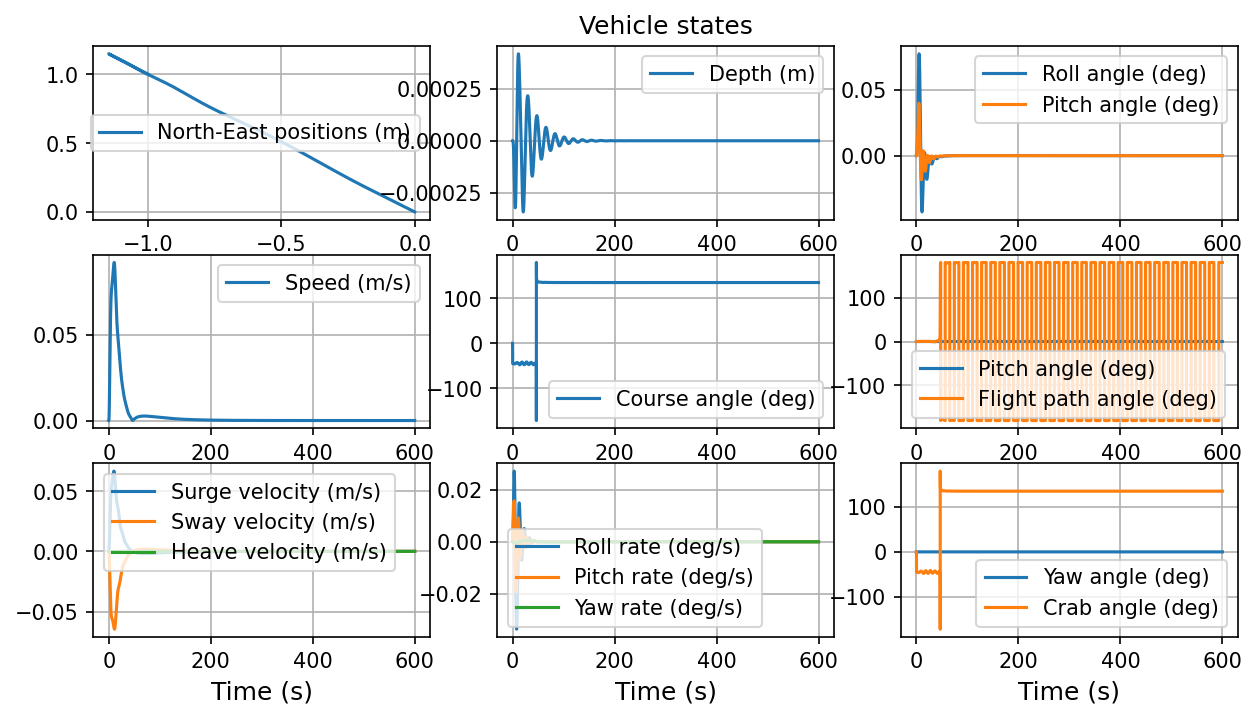

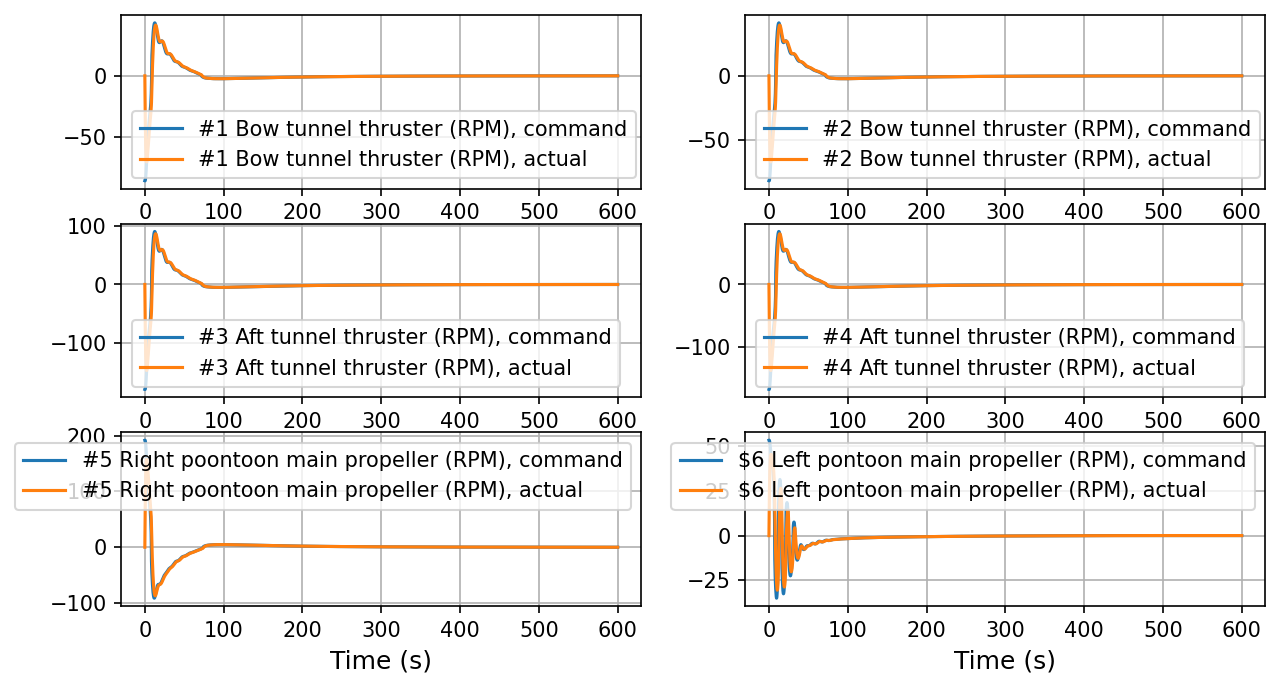

In [104]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [105]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

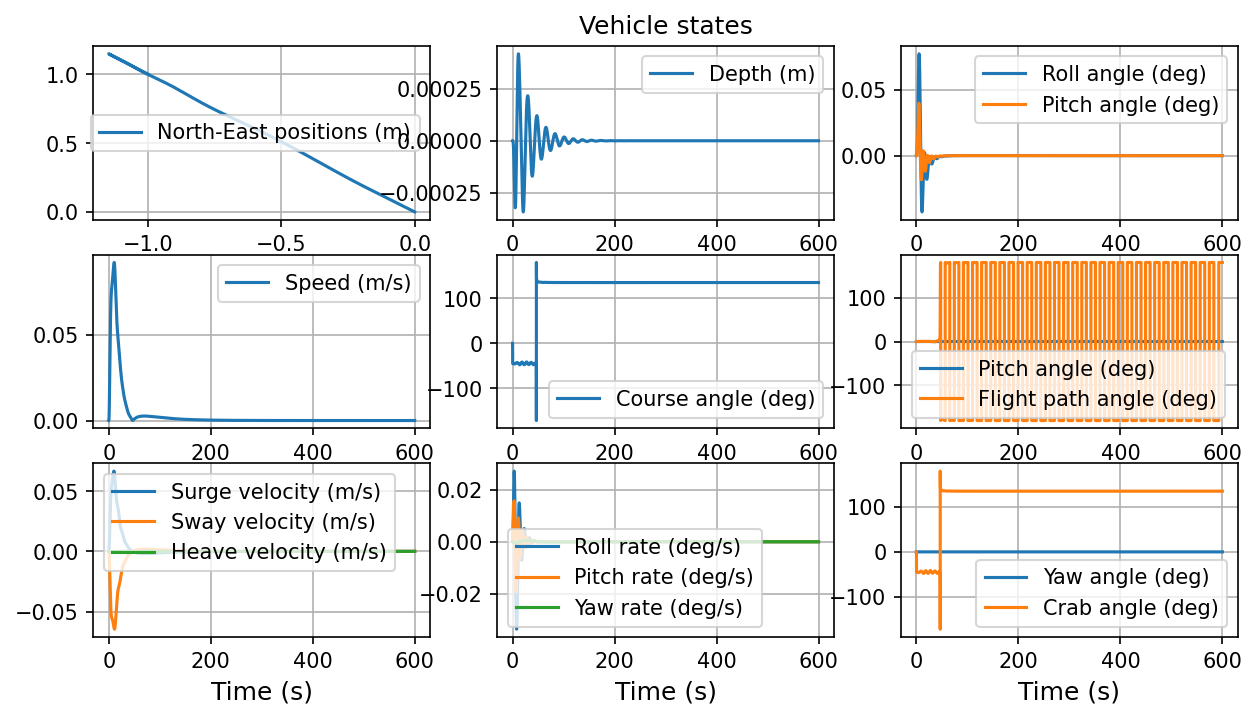

In [106]:
plotVehicleStates(simTime, simData, 3)

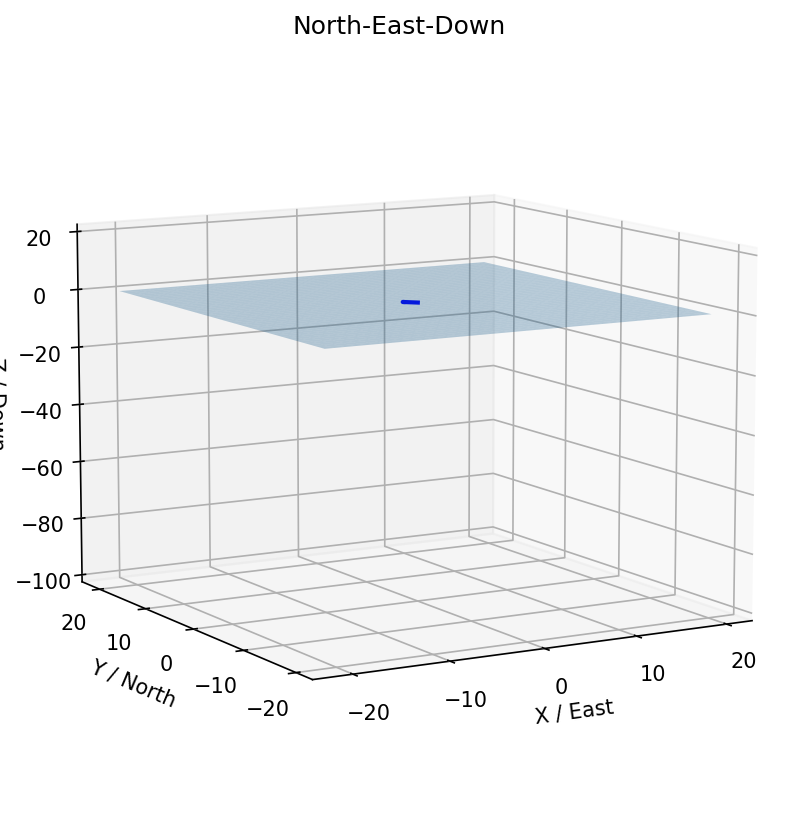

In [107]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [108]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [109]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

### Dynamics

In [110]:
def dynamic_func(t, Q, coefs, T, calibr):
    
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    del_t = idx-T.my_t
    if del_t<0:
        idx=T.my_t
        
    x_ve = simData[:, 0][idx]
    y_ve = simData[:, 1][idx]
    z_ve = simData[:, 2][idx]
    phi_ve = ssa(simData[:, 3][idx])
    theta_ve = ssa(simData[:, 4][idx])
    psi_ve = ssa(simData[:, 5][idx])
    
    RET = Ret(φ,θ,ψ)

    vessel_movement = np.zeros(6)
    
    
    vessel_movement[0] = (x_ve - T.x_ve)
    vessel_movement[1] = (y_ve - T.y_ve)
    vessel_movement[2] = (z_ve - T.z_ve)
    vessel_movement[3] = (phi_ve - T.phi_ve)
    vessel_movement[4] = (theta_ve - T.theta_ve)
    vessel_movement[5] = (psi_ve - T.psi_ve)

#     vessel_movement/=calibr
    
    vessel_move = np.zeros(6*len(z0))
    
    vessel_move[-6] = vessel_movement[0]
    vessel_move[-5] = vessel_movement[1]
    vessel_move[-4] = vessel_movement[2]
    vessel_move[-3] = vessel_movement[3]
    vessel_move[-2] = vessel_movement[4]
    vessel_move[-1] = vessel_movement[5]
    

    fors, mom, angle = PipeForce(x, y, z, list(vessel_move), coefs)
    
    Z0 = fors.squeeze()
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T

    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,ik->ij', Π(φ,θ,ψ), angle).squeeze()    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0)

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################

    T.my_t=idx
    T.x_ve=x_ve
    T.y_ve=y_ve
    T.z_ve=z_ve
    T.phi_ve = phi_ve
    T.theta_ve = theta_ve
    T.psi_ve = psi_ve

    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy, 
                        dz, ddz, 
                        dφ, ddφ, 
                        dθ, ddθ, 
                        dψ, ddψ
                       ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(φ, θ, ψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
    return ans

In [111]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.000001 for i in range(N)]),
                                          np.array([0.001257*i/N for i in range(N)]))

In [112]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(coefs, T_, vessel_motion_calibration_coefficient,))
print(datetime.now() - startTime1)

Physical time:  9.84646067382047e-08  Iteration wall-clock time:  0:00:00.650560
Physical time:  1.0076405811051403  Iteration wall-clock time:  0:05:27.569818
Physical time:  2.0014874557445674  Iteration wall-clock time:  0:05:24.577203
Physical time:  3.0014548445985785  Iteration wall-clock time:  0:05:22.914059
Physical time:  4.005079955191733  Iteration wall-clock time:  0:04:35.445707
0:26:52.236792


In [113]:
# max axial tension
T_.top_tension

6.6272245608080396e+44

In [114]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.0001262910573470688

### Results

In [115]:
fin=us_

In [116]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.846e-06 ...  4.979e+00  5.000e+00]
        y: [[ 0.000e+00  3.337e-25 ...  1.898e-05  1.914e-05]
            [ 1.103e+01  1.103e+01 ...  1.092e+01  1.092e+01]
            ...
            [ 0.000e+00 -4.608e-20 ... -6.133e-17 -6.056e-17]
            [ 0.000e+00 -2.088e-20 ... -1.960e-16 -1.962e-16]]
      sol: None
 t_events: None
 y_events: None
     nfev: 4472
     njev: 0
      nlu: 0

In [117]:
t=fin.t

In [118]:
fin=fin.y.T

In [119]:
t.shape, fin.shape

((502,), (502, 240))

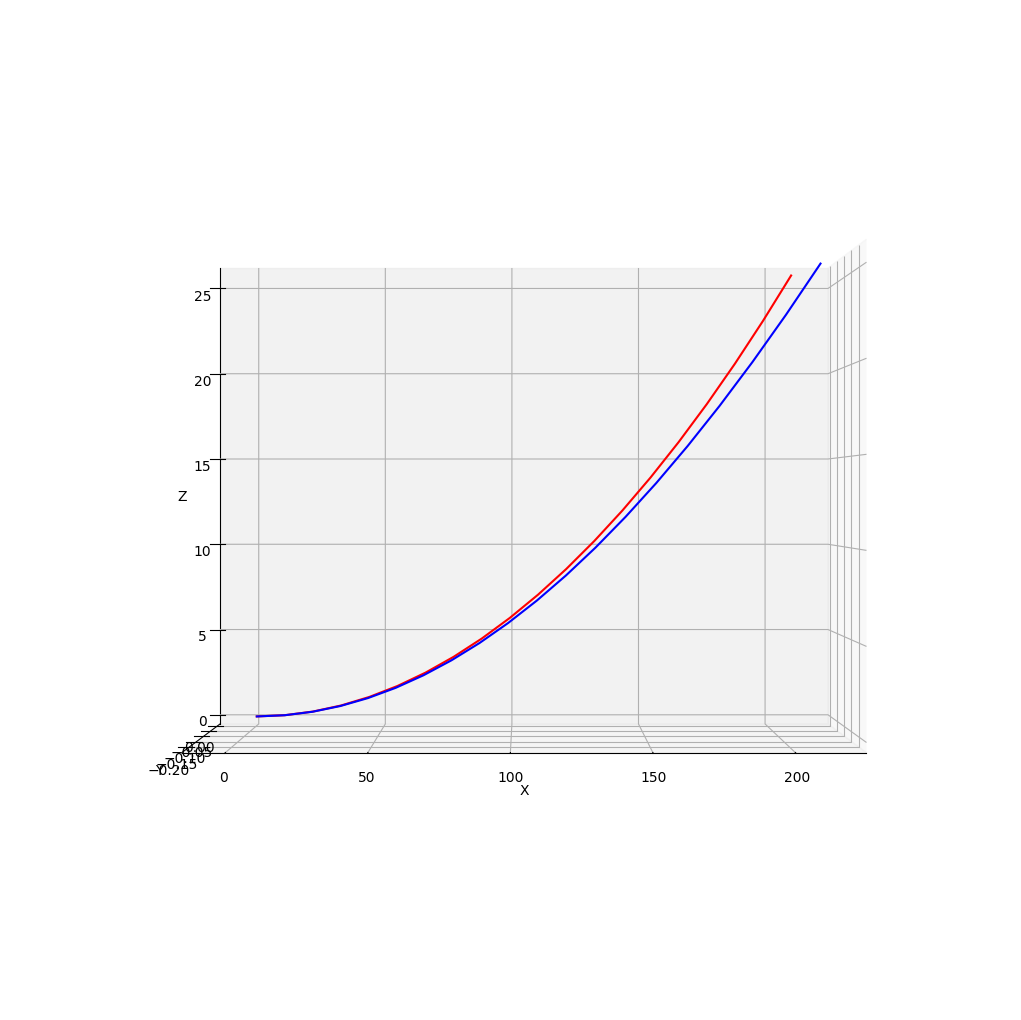

In [120]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [121]:
X,Y,Z

(array([1.91367570e-05, 1.09161197e+01, 2.18470171e+01, 3.27891872e+01,
        4.37409321e+01, 5.47017430e+01, 6.56719649e+01, 7.66526612e+01,
        8.76454767e+01, 9.86526328e+01, 1.09676729e+02, 1.20720530e+02,
        1.31786269e+02, 1.42874590e+02, 1.53982833e+02, 1.65103762e+02,
        1.76228230e+02, 1.87350050e+02, 1.98466313e+02, 2.09576008e+02]),
 array([ 1.91358989e-09,  3.66415842e-04, -5.19515599e-04, -2.74550321e-03,
        -6.35811328e-03, -1.13654286e-02, -1.77650113e-02, -2.55544827e-02,
        -3.47335537e-02, -4.53040611e-02, -5.72696351e-02, -7.06353005e-02,
        -8.54071375e-02, -1.01591123e-01, -1.19190738e-01, -1.38205619e-01,
        -1.58632130e-01, -1.80466973e-01, -2.03710029e-01, -2.28360374e-01]),
 array([-2.45896455e-03,  6.62437016e-02,  2.72463263e-01,  6.16280048e-01,
         1.09783187e+00,  1.71729670e+00,  2.47487404e+00,  3.37079784e+00,
         4.40535344e+00,  5.57889724e+00,  6.89186362e+00,  8.34476303e+00,
         9.93813425e+00,  1.

In [122]:
X0,Y0,Z0

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.07074654,  0.28299779,  0.63678871,  1.13217754,
         1.76924585,  2.54809852,  3.46886379,  4.53169324,  5.73676187,
         7.08426809,  8.57443374, 10.20750417, 11.98374825, 13.90345843,
        15.96695076, 18.17456499, 20.52666459, 23.02363679, 25.66589272]))

In [123]:
us=fin.T

In [124]:
us.shape

(240, 502)

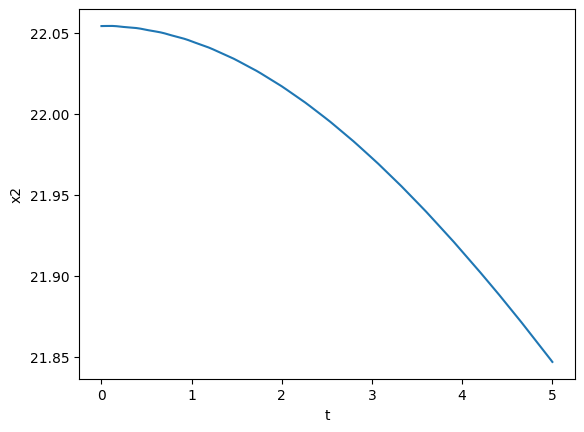

In [125]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

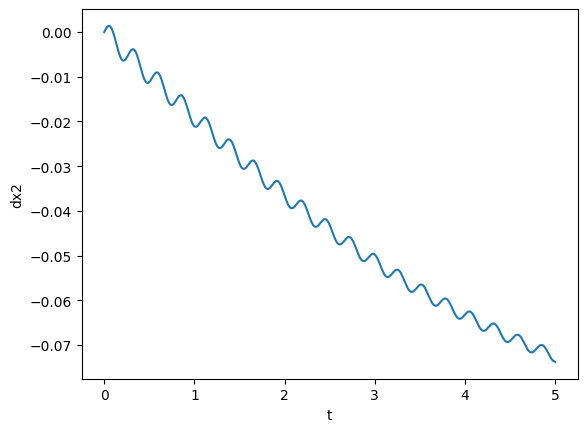

In [126]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

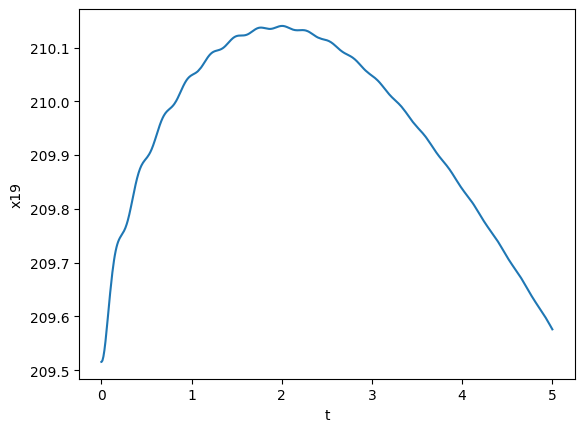

In [127]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

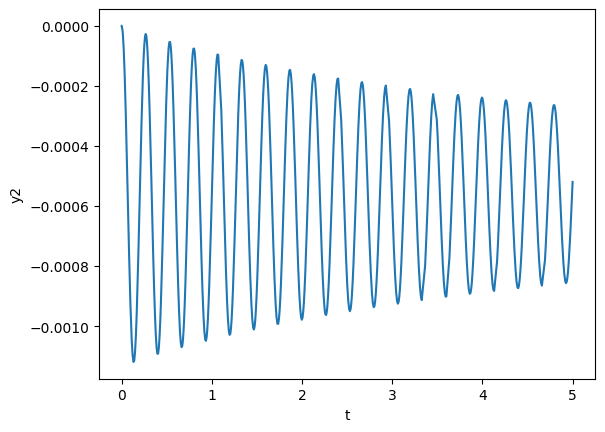

In [128]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

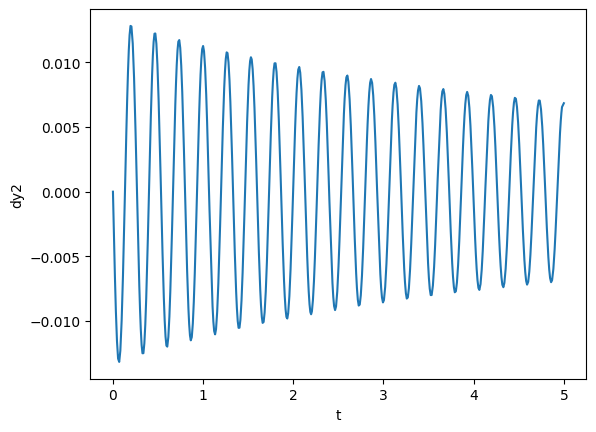

In [129]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

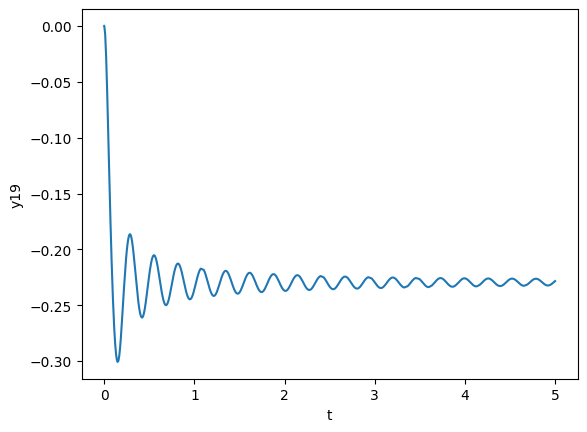

In [130]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

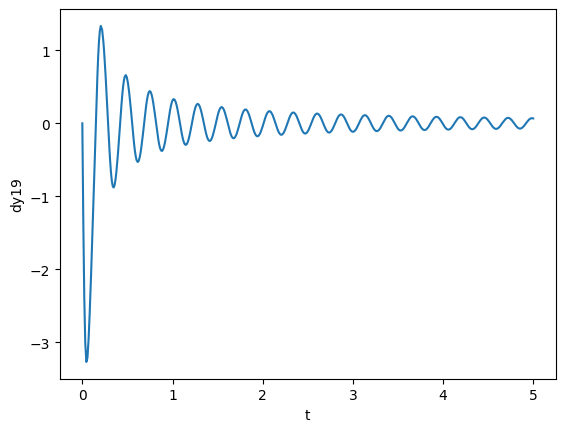

In [131]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

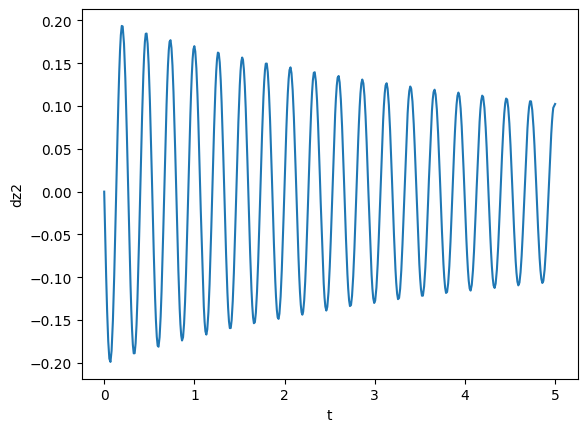

In [132]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

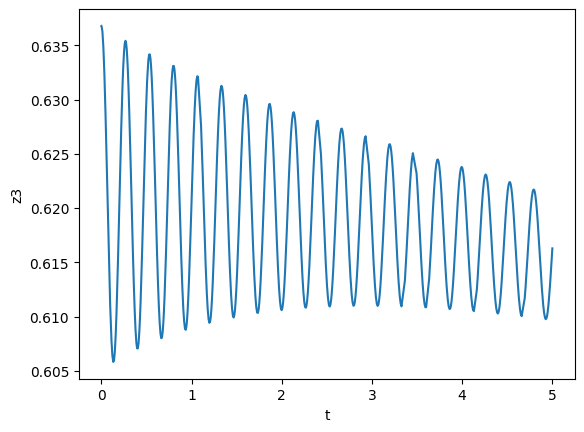

In [133]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

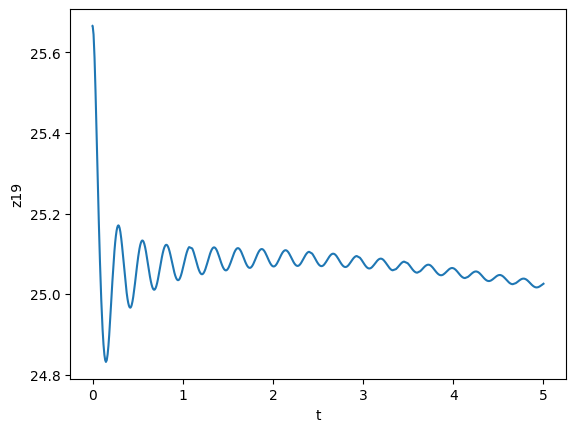

In [134]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

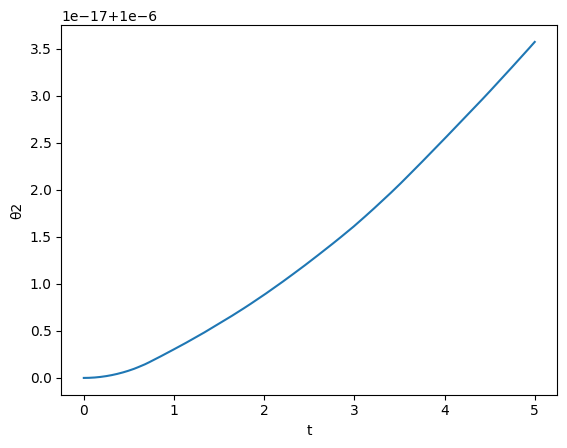

In [135]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

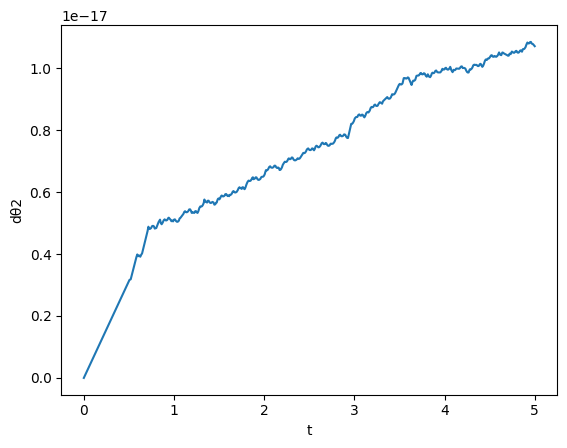

In [136]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

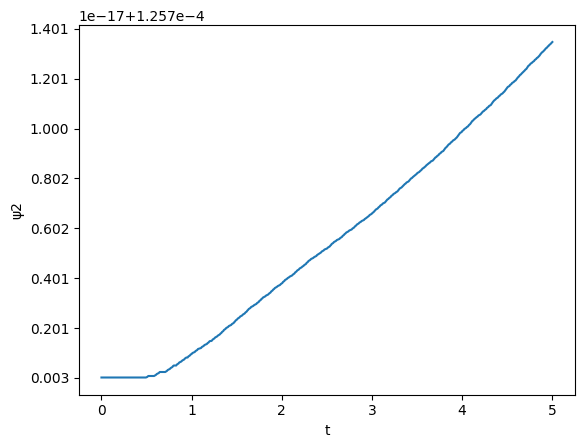

In [137]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

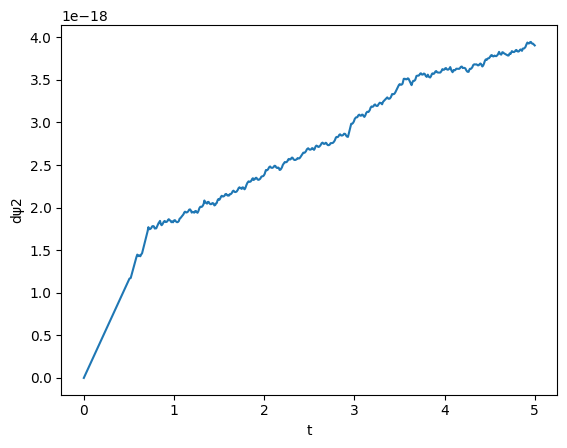

In [138]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

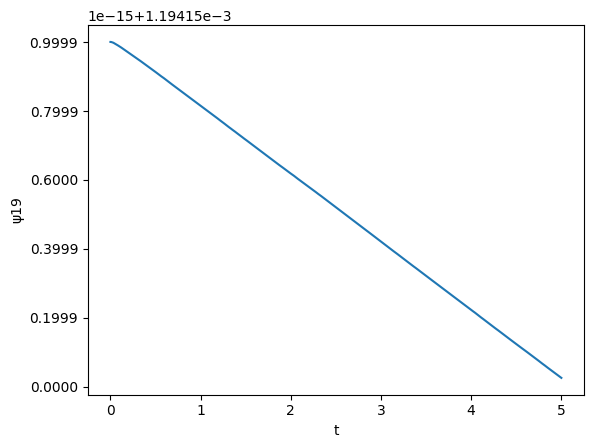

In [139]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [140]:
X010=us.T[:,0*N:1*N]

In [141]:
Y010=us.T[:,2*N:3*N]

In [142]:
Z010=us.T[:,4*N:5*N]

In [143]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 30                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 300]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 40]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()